In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [4]:
# This is the official implementation of the single-phase model for multi-class CVD classification presented in:
# Srikijkasemwat N, Villarroel M, Banerjee A,
# "Multi-Phase Deep Learning Model for Automated Disease Classification from Cardiac Cine MRI",
# Journal of the Royal Society Interface, 2025.
# Author: Srikijkasemwat N
# Date : August 27, 2025
#
# The training code based on:
# Chilamkurthy, S. "Transfer Learning for Computer Vision Tutorial."
# PyTorch Tutorials, https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# Accessed November 2023.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from tempfile import TemporaryDirectory
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
cudnn.benchmark = True
from torchvision.io.image import read_image
from torchvision.transforms.functional import normalize, resize, to_pil_image

### 1. Data Preparation for Single-Phase Cardiac MRI Classification  
**Mid-Cavity Slice Selection and Heart-Centred First Crop**

This section prepares the ACDC cardiac cine MRI data for classification.  
The workflow identifies the mid-cavity short-axis slice, localizes the heart using the segmentation mask, computes the heart centre, and defines a larger first crop around the heart.

The maximum heart height and width are computed from the training set only.  
These values are then used to define a first crop enlarged by a factor of 1.5, which helps preserve the cardiac region during later rotation-based augmentation.

In [5]:
import os
import json
import numpy as np
import nibabel as nib
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
ACDC_ROOT = r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database"
TRAIN_DIR = os.path.join(ACDC_ROOT, "training")
TEST_DIR = os.path.join(ACDC_ROOT, "testing")

CACHE_ROOT = r"C:\Users\manoj\Desktop\Thesis\acdc_cached_firstcrop"
os.makedirs(CACHE_ROOT, exist_ok=True)

CLASS_MAP = {
    "NOR": "NOR",
    "MINF": "MI",
    "DCM": "DCM",
    "HCM": "HCM",
    "RV": "ARV",
}

CLASS_TO_IDX = {
    "ARV": 0,
    "DCM": 1,
    "HCM": 2,
    "MI": 3,
    "NOR": 4,
}

# ============================================================
# UTILS
# ============================================================
def parse_cfg(cfg_path: str) -> dict:
    cfg = {}
    with open(cfg_path, "r", encoding="utf-8") as f:
        for line in f:
            if ":" in line:
                k, v = line.strip().split(":", 1)
                cfg[k.strip()] = v.strip()
    return cfg


def load_nii(path: str) -> np.ndarray:
    return nib.load(path).get_fdata()


def bbox_from_mask(mask_2d: np.ndarray):
    ys, xs = np.where(mask_2d > 0)
    if ys.size == 0:
        return None
    y_min, y_max = int(ys.min()), int(ys.max())
    x_min, x_max = int(xs.min()), int(xs.max())
    return y_min, y_max, x_min, x_max


def center_from_bbox(bb):
    y_min, y_max, x_min, x_max = bb
    cy = (y_min + y_max) // 2
    cx = (x_min + x_max) // 2
    return cy, cx


def choose_mid_cavity_slice(mask_3d: np.ndarray) -> int:
    areas = [int(np.sum(mask_3d[:, :, z] > 0)) for z in range(mask_3d.shape[2])]
    return int(np.argmax(areas))


def crop_with_padding(img_2d: np.ndarray, cy: int, cx: int, crop_h: int, crop_w: int) -> np.ndarray:
    H, W = img_2d.shape
    half_h = crop_h // 2
    half_w = crop_w // 2

    y1 = cy - half_h
    x1 = cx - half_w
    y2 = y1 + crop_h
    x2 = x1 + crop_w

    out = np.zeros((crop_h, crop_w), dtype=np.float32)

    src_y1 = max(0, y1)
    src_y2 = min(H, y2)
    src_x1 = max(0, x1)
    src_x2 = min(W, x2)

    dst_y1 = src_y1 - y1
    dst_y2 = dst_y1 + (src_y2 - src_y1)
    dst_x1 = src_x1 - x1
    dst_x2 = dst_x1 + (src_x2 - src_x1)

    out[dst_y1:dst_y2, dst_x1:dst_x2] = img_2d[src_y1:src_y2, src_x1:src_x2]
    return out


# ============================================================
# STEP 1: COMPUTE GLOBAL HEART SIZE FROM TRAINING ED MASKS
# ============================================================
def compute_global_max_heart_size(train_dir: str):
    max_height = 0
    max_width = 0
    processed = 0

    for patient in sorted(os.listdir(train_dir)):
        patient_dir = os.path.join(train_dir, patient)
        if not os.path.isdir(patient_dir):
            continue

        cfg_path = os.path.join(patient_dir, "Info.cfg")
        if not os.path.exists(cfg_path):
            continue

        cfg = parse_cfg(cfg_path)
        group = cfg.get("Group")
        if group not in CLASS_MAP:
            continue

        ed = int(cfg.get("ED", 0))
        if ed <= 0:
            continue

        ed_mask_path = os.path.join(patient_dir, f"{patient}_frame{ed:02d}_gt.nii.gz")
        if not os.path.exists(ed_mask_path):
            continue

        ed_mask_3d = load_nii(ed_mask_path)
        z_mid = choose_mid_cavity_slice(ed_mask_3d)
        mask_2d = ed_mask_3d[:, :, z_mid]

        bb = bbox_from_mask(mask_2d)
        if bb is None:
            continue

        y_min, y_max, x_min, x_max = bb
        h = y_max - y_min + 1
        w = x_max - x_min + 1

        max_height = max(max_height, h)
        max_width = max(max_width, w)
        processed += 1

    return max_height, max_width, processed


max_h, max_w, processed = compute_global_max_heart_size(TRAIN_DIR)
first_crop_h = int(1.5 * max_h)
first_crop_w = int(1.5 * max_w)

print("Processed training patients:", processed)
print("Max heart size:", max_h, "x", max_w)
print("First crop size:", first_crop_h, "x", first_crop_w)

meta = {
    "max_height": int(max_h),
    "max_width": int(max_w),
    "first_crop_h": int(first_crop_h),
    "first_crop_w": int(first_crop_w),
}

with open(os.path.join(CACHE_ROOT, "cache_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# ============================================================
# STEP 2: CACHE FIRST-CROP ARRAYS
# ============================================================
index_records = []

for split_dir, split_name in [(TRAIN_DIR, "train"), (TEST_DIR, "test")]:
    print(f"\nCaching {split_name.upper()} ...")

    for patient in sorted(os.listdir(split_dir)):
        patient_dir = os.path.join(split_dir, patient)
        if not os.path.isdir(patient_dir):
            continue

        cfg_path = os.path.join(patient_dir, "Info.cfg")
        if not os.path.exists(cfg_path):
            continue

        cfg = parse_cfg(cfg_path)
        group = cfg.get("Group")
        if group not in CLASS_MAP:
            continue

        class_name = CLASS_MAP[group]
        label = CLASS_TO_IDX[class_name]

        ed = int(cfg.get("ED", 0))
        es = int(cfg.get("ES", 0))
        if ed <= 0 or es <= 0:
            continue

        fourd_path = os.path.join(patient_dir, f"{patient}_4d.nii.gz")
        ed_mask_path = os.path.join(patient_dir, f"{patient}_frame{ed:02d}_gt.nii.gz")

        if not os.path.exists(fourd_path) or not os.path.exists(ed_mask_path):
            continue

        fourd = load_nii(fourd_path)
        ed_mask_3d = load_nii(ed_mask_path)

        if fourd.ndim != 4 or ed_mask_3d.ndim != 3:
            continue

        H, W, Z, T = fourd.shape
        if not (1 <= ed <= T and 1 <= es <= T):
            continue

        z_mid = choose_mid_cavity_slice(ed_mask_3d)
        mask_2d = ed_mask_3d[:, :, z_mid]

        bb = bbox_from_mask(mask_2d)
        if bb is None:
            continue

        cy, cx = center_from_bbox(bb)

        ed_img_2d = fourd[:, :, z_mid, ed - 1]
        es_img_2d = fourd[:, :, z_mid, es - 1]

        cropped_ed = crop_with_padding(ed_img_2d, cy, cx, first_crop_h, first_crop_w).astype(np.float32)
        cropped_es = crop_with_padding(es_img_2d, cy, cx, first_crop_h, first_crop_w).astype(np.float32)

        patient_cache_dir = os.path.join(CACHE_ROOT, split_name, patient)
        os.makedirs(patient_cache_dir, exist_ok=True)

        ed_cache_path = os.path.join(patient_cache_dir, "ED_firstcrop.npy")
        es_cache_path = os.path.join(patient_cache_dir, "ES_firstcrop.npy")

        np.save(ed_cache_path, cropped_ed)
        np.save(es_cache_path, cropped_es)

        index_records.append({
            "split": split_name,
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "ed_path": ed_cache_path,
            "es_path": es_cache_path
        })

        print(f"Cached {split_name} | {patient} | {class_name}")

index_path = os.path.join(CACHE_ROOT, "cache_index.json")
with open(index_path, "w", encoding="utf-8") as f:
    json.dump(index_records, f, indent=2)

print("\nCaching complete.")
print("Index file:", index_path)

Processed training patients: 100
Max heart size: 158 x 137
First crop size: 237 x 205

Caching TRAIN ...
Cached train | patient001 | DCM
Cached train | patient002 | DCM
Cached train | patient003 | DCM
Cached train | patient004 | DCM
Cached train | patient005 | DCM
Cached train | patient006 | DCM
Cached train | patient007 | DCM
Cached train | patient008 | DCM
Cached train | patient009 | DCM
Cached train | patient010 | DCM
Cached train | patient011 | DCM
Cached train | patient012 | DCM
Cached train | patient013 | DCM
Cached train | patient014 | DCM
Cached train | patient015 | DCM
Cached train | patient016 | DCM
Cached train | patient017 | DCM
Cached train | patient018 | DCM
Cached train | patient019 | DCM
Cached train | patient020 | DCM
Cached train | patient021 | HCM
Cached train | patient022 | HCM
Cached train | patient023 | HCM
Cached train | patient024 | HCM
Cached train | patient025 | HCM
Cached train | patient026 | HCM
Cached train | patient027 | HCM
Cached train | patient028 | HCM

### 2. Image Transformation pipeline


**Training Augmentation and Evaluation Preparation**

This section defines the transformation steps applied before the image is passed to the neural network.

The training pipeline includes controlled augmentation through brightness adjustment, contrast adjustment, and random rotation.  
After augmentation, a centre crop is applied, followed by resizing to 128 × 128, tensor conversion, and normalization.

For evaluation and testing, only deterministic processing is used so that performance is measured on stable and reproducible inputs.

In [6]:
import json
from torchvision import transforms

with open(os.path.join(CACHE_ROOT, "cache_meta.json"), "r", encoding="utf-8") as f:
    cache_meta = json.load(f)

max_h = int(cache_meta["max_height"])
max_w = int(cache_meta["max_width"])

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

paper_train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=[0.5, 1.5], contrast=[0.5, 1.5]),
    transforms.RandomRotation((-30, 30)),
    transforms.CenterCrop((max_h, max_w)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

paper_eval_transform = transforms.Compose([
    transforms.CenterCrop((max_h, max_w)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Transforms ready.")
print("Second crop size:", (max_h, max_w))
print("Final input size:", (128, 128))

Transforms ready.
Second crop size: (158, 137)
Final input size: (128, 128)


### 3. Dataset Construction for Single-Phase Classification  
**Direct Loading from Cine MRI and Segmentation Masks**

This section constructs the dataset for single-phase classification by loading the original 4D cine MRI volumes and the corresponding segmentation masks directly.

For each patient, the loader:
- reads the MRI volume and segmentation mask
- selects the mid-cavity slice
- computes the heart-centred first crop
- extracts the chosen cardiac phase
- applies the transformation pipeline
- returns the processed image together with its class label

This design keeps the full data flow transparent and ensures that all slice-selection and cropping operations are performed consistently during training and evaluation.

In [7]:
import json
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

with open(os.path.join(CACHE_ROOT, "cache_index.json"), "r", encoding="utf-8") as f:
    cache_index = json.load(f)


def minmax_to_uint8(img_2d: np.ndarray) -> np.ndarray:
    x = img_2d.astype(np.float32)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    x = (x * 255.0).clip(0, 255).astype(np.uint8)
    return x


class CachedSinglePhaseDataset(Dataset):
    def __init__(self, index_records, split, phase="ES", transform=None):
        assert phase in ["ED", "ES"]
        self.phase = phase
        self.transform = transform
        self.records = [r for r in index_records if r["split"] == split]
        self.classes = ["ARV", "DCM", "HCM", "MI", "NOR"]
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        arr = np.load(r["ed_path"] if self.phase == "ED" else r["es_path"])
        arr_u8 = minmax_to_uint8(arr)
        img = Image.fromarray(arr_u8, mode="L").convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, r["label"]


class CachedMultiPhaseDataset(Dataset):
    def __init__(self, index_records, split, transform=None):
        self.transform = transform
        self.records = [r for r in index_records if r["split"] == split]
        self.classes = ["ARV", "DCM", "HCM", "MI", "NOR"]
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        ed_arr = np.load(r["ed_path"])
        es_arr = np.load(r["es_path"])

        ed_u8 = minmax_to_uint8(ed_arr)
        es_u8 = minmax_to_uint8(es_arr)

        ed_img = Image.fromarray(ed_u8, mode="L").convert("RGB")
        es_img = Image.fromarray(es_u8, mode="L").convert("RGB")

        if self.transform is not None:
            seed = np.random.randint(0, 2**31 - 1)

            torch.manual_seed(seed)
            ed_img = self.transform(ed_img)

            torch.manual_seed(seed)
            es_img = self.transform(es_img)

        return ed_img, es_img, r["label"]


# ===================== CREATE DATASETS =====================
train_dataset_ES = CachedSinglePhaseDataset(cache_index, split="train", phase="ES", transform=paper_train_transform)
eval_train_dataset_ES = CachedSinglePhaseDataset(cache_index, split="train", phase="ES", transform=paper_eval_transform)
test_dataset_ES = CachedSinglePhaseDataset(cache_index, split="test", phase="ES", transform=paper_eval_transform)

train_dataset_ED = CachedSinglePhaseDataset(cache_index, split="train", phase="ED", transform=paper_train_transform)
eval_train_dataset_ED = CachedSinglePhaseDataset(cache_index, split="train", phase="ED", transform=paper_eval_transform)
test_dataset_ED = CachedSinglePhaseDataset(cache_index, split="test", phase="ED", transform=paper_eval_transform)

train_dataset_multi = CachedMultiPhaseDataset(cache_index, split="train", transform=paper_train_transform)
eval_train_dataset_multi = CachedMultiPhaseDataset(cache_index, split="train", transform=paper_eval_transform)
test_dataset_multi = CachedMultiPhaseDataset(cache_index, split="test", transform=paper_eval_transform)

print("ES train/test:", len(train_dataset_ES), len(test_dataset_ES))
print("ED train/test:", len(train_dataset_ED), len(test_dataset_ED))
print("Multi train/test:", len(train_dataset_multi), len(test_dataset_multi))

ES train/test: 100 50
ED train/test: 100 50
Multi train/test: 100 50


In [8]:
k_folds = 4
num_epochs = 150
results = {}

In [9]:
# In our stratified k-fold cross-validation, we wanted to compare the performance of the different
# deep learning models on the same sets of 4 folds, so we defined all 4 folds and kept them
# consistent when training different models.

train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0 = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [ 0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1=[3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [ 0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2=[2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [ 0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3=[1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

In [10]:
train_ids_fold = []
train_ids_fold.append(train_ids_fold0)
train_ids_fold.append(train_ids_fold1)
train_ids_fold.append(train_ids_fold2)
train_ids_fold.append(train_ids_fold3)

val_ids_fold = []
val_ids_fold.append(val_ids_fold0)
val_ids_fold.append(val_ids_fold1)
val_ids_fold.append(val_ids_fold2)
val_ids_fold.append(val_ids_fold3)

### 4. Training of the ED Single-Phase Classification Model  
**ResNet-34 with 4-Fold Cross-Validation**

#### Overview
This section trains the end-diastolic (ED) single-phase classification model using a ResNet-34 backbone.

#### Model Configuration
- Backbone network: **ResNet-34**
- Weight initialization: **ImageNet pretrained**
- Fine-tuning strategy: **all layers updated during training**
- Output layer: **fully connected layer with 5 diagnostic classes**

#### Training Setup
- Loss function: **cross-entropy loss**
- Optimizer: **Adam**
- Initial learning rate: **0.001**
- Learning-rate schedule: **reduced by a factor of 10 every 20 epochs**
- Number of epochs: **150**
- Batch size: **20**

#### Cross-Validation Strategy
- Training is performed using **4 predefined stratified folds**
- For each fold:
  - one subset is used for training
  - one subset is used for validation
- The model checkpoint is saved at the epoch with the **highest validation accuracy**

#### Performance Recording
For each fold, the following validation results are stored:
- accuracy
- macro F1-score
- macro sensitivity
- macro specificity

#### Visual Outputs
For each fold, the training process produces:
- loss curves
- accuracy curves
- classification report
- normalized confusion matrix

Using device: cuda:0
Classes: ['ARV', 'DCM', 'HCM', 'MI', 'NOR']

Starting 4-fold training for ED single-phase model...


FOLD 0
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=25.33%  val_acc=16.00%  val_f1=5.52%
Epoch 002/150  train_acc=32.00%  val_acc=24.00%  val_f1=13.52%
Epoch 003/150  train_acc=46.67%  val_acc=16.00%  val_f1=10.45%
Epoch 004/150  train_acc=49.33%  val_acc=24.00%  val_f1=14.69%
Epoch 005/150  train_acc=60.00%  val_acc=28.00%  val_f1=19.67%
Epoch 006/150  train_acc=57.33%  val_acc=24.00%  val_f1=12.86%
Epoch 007/150  train_acc=69.33%  val_acc=28.00%  val_f1=24.38%
Epoch 008/150  train_acc=86.67%  val_acc=24.00%  val_f1=18.72%
Epoch 009/150  train_acc=78.67%  val_acc=32.00%  val_f1=22.53%
Epoch 010/150  train_acc=81.33%  val_acc=28.00%  val_f1=20.34%
Epoch 011/150  train_acc=86.67%  val_acc=48.00%  val_f1=42.56%
Epoch 012/150  train_acc=90.67%  val_acc=24.00%  val_f1=19.67%
Epoch 013/150  train_acc=84.00%  val_acc=24.00%  val_f1=21.80%
Epoch

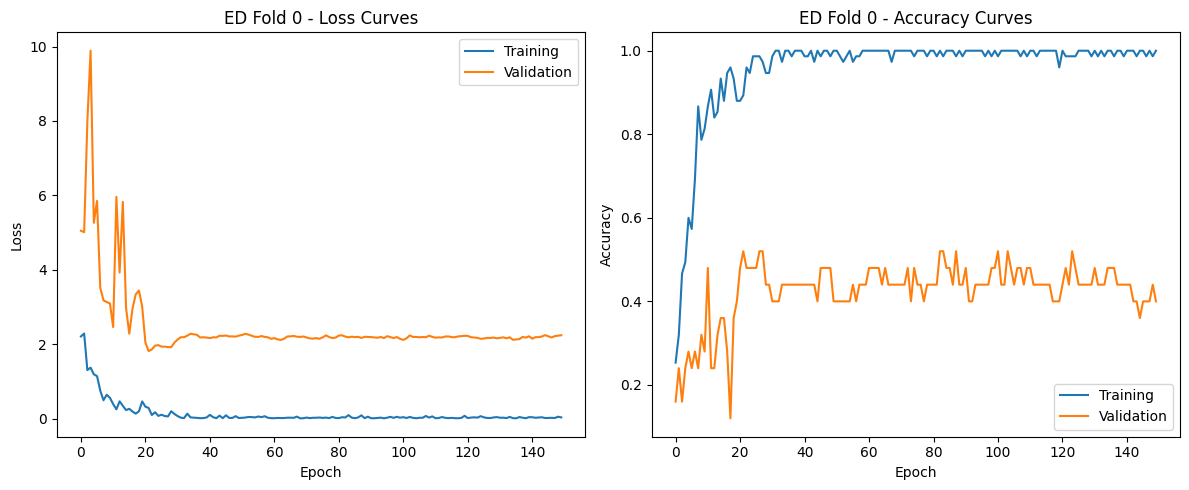


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.3750    0.6000    0.4615         5
         DCM     1.0000    0.4000    0.5714         5
         HCM     0.7500    0.6000    0.6667         5
          MI     0.7500    0.6000    0.6667         5
         NOR     0.2857    0.4000    0.3333         5

    accuracy                         0.5200        25
   macro avg     0.6321    0.5200    0.5399        25
weighted avg     0.6321    0.5200    0.5399        25



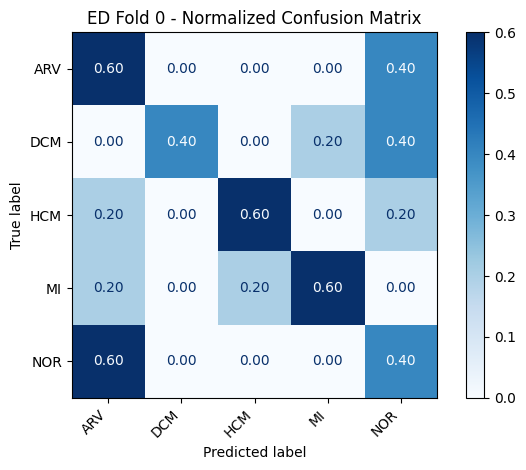


FOLD 1
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=20.00%  val_acc=28.00%  val_f1=23.62%
Epoch 002/150  train_acc=41.33%  val_acc=32.00%  val_f1=22.16%
Epoch 003/150  train_acc=50.67%  val_acc=28.00%  val_f1=22.60%
Epoch 004/150  train_acc=50.67%  val_acc=28.00%  val_f1=16.96%
Epoch 005/150  train_acc=56.00%  val_acc=20.00%  val_f1=6.67%
Epoch 006/150  train_acc=70.67%  val_acc=32.00%  val_f1=23.33%
Epoch 007/150  train_acc=74.67%  val_acc=24.00%  val_f1=12.41%
Epoch 008/150  train_acc=65.33%  val_acc=48.00%  val_f1=38.43%
Epoch 009/150  train_acc=86.67%  val_acc=56.00%  val_f1=49.39%
Epoch 010/150  train_acc=85.33%  val_acc=60.00%  val_f1=50.00%
Epoch 011/150  train_acc=86.67%  val_acc=44.00%  val_f1=34.86%
Epoch 012/150  train_acc=86.67%  val_acc=48.00%  val_f1=47.33%
Epoch 013/150  train_acc=88.00%  val_acc=48.00%  val_f1=40.00%
Epoch 014/150  train_acc=86.67%  val_acc=24.00%  val_f1=11.97%
Epoch 015/150  train_acc=88.00%  val_acc=52.00%  val_f1=43.67%


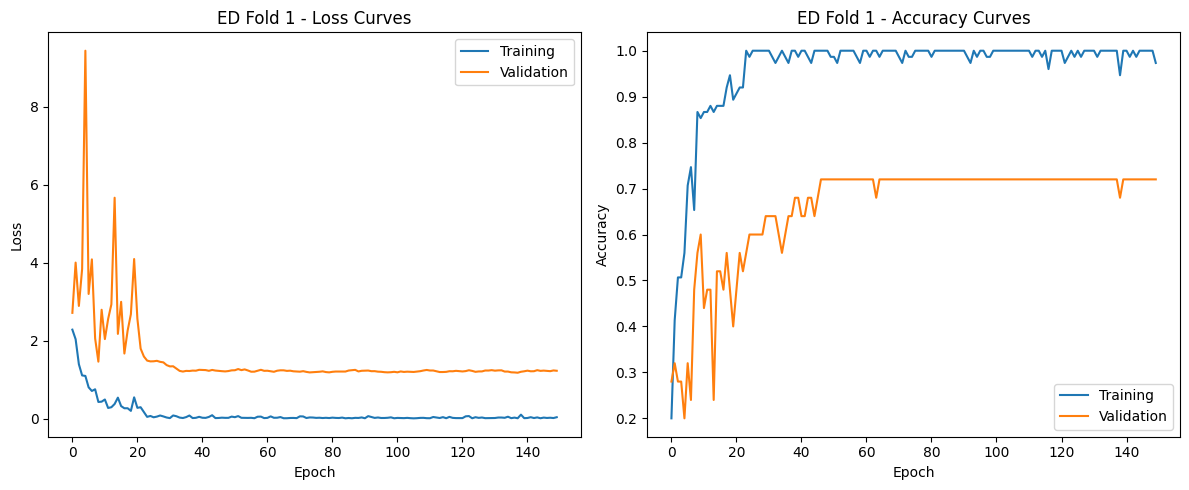


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.6667    0.8000    0.7273         5
         DCM     0.6667    0.8000    0.7273         5
         HCM     0.8333    1.0000    0.9091         5
          MI     0.5000    0.2000    0.2857         5
         NOR     0.8000    0.8000    0.8000         5

    accuracy                         0.7200        25
   macro avg     0.6933    0.7200    0.6899        25
weighted avg     0.6933    0.7200    0.6899        25



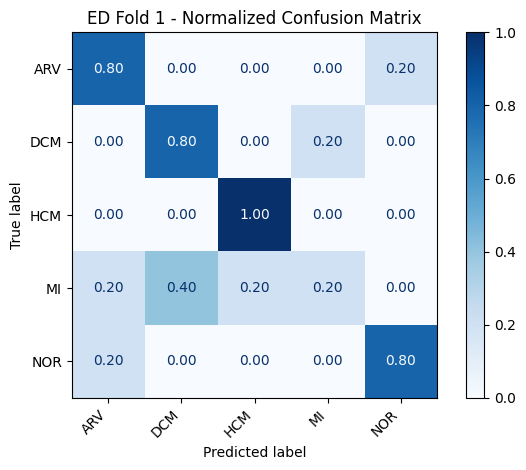


FOLD 2
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=20.00%  val_acc=20.00%  val_f1=6.90%
Epoch 002/150  train_acc=36.00%  val_acc=24.00%  val_f1=12.41%
Epoch 003/150  train_acc=46.67%  val_acc=20.00%  val_f1=15.75%
Epoch 004/150  train_acc=49.33%  val_acc=24.00%  val_f1=16.67%
Epoch 005/150  train_acc=68.00%  val_acc=32.00%  val_f1=24.15%
Epoch 006/150  train_acc=76.00%  val_acc=44.00%  val_f1=37.96%
Epoch 007/150  train_acc=84.00%  val_acc=40.00%  val_f1=34.38%
Epoch 008/150  train_acc=70.67%  val_acc=40.00%  val_f1=38.33%
Epoch 009/150  train_acc=81.33%  val_acc=36.00%  val_f1=36.62%
Epoch 010/150  train_acc=85.33%  val_acc=44.00%  val_f1=38.10%
Epoch 011/150  train_acc=77.33%  val_acc=52.00%  val_f1=54.76%
Epoch 012/150  train_acc=86.67%  val_acc=52.00%  val_f1=49.97%
Epoch 013/150  train_acc=82.67%  val_acc=56.00%  val_f1=54.33%
Epoch 014/150  train_acc=92.00%  val_acc=36.00%  val_f1=30.33%
Epoch 015/150  train_acc=86.67%  val_acc=52.00%  val_f1=50.52%


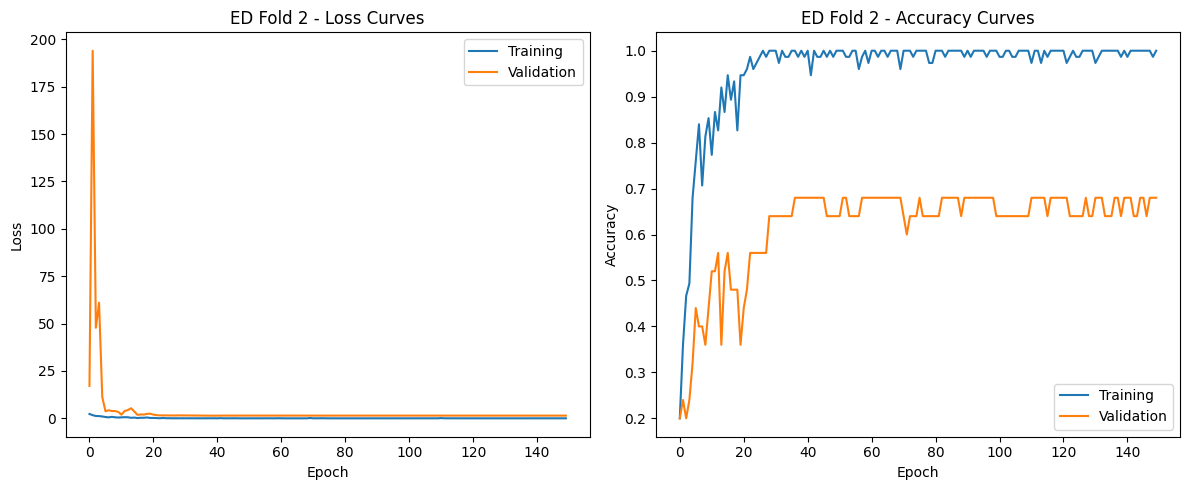


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.8000    0.8000    0.8000         5
         DCM     0.6250    1.0000    0.7692         5
         HCM     1.0000    0.8000    0.8889         5
          MI     0.6000    0.6000    0.6000         5
         NOR     0.3333    0.2000    0.2500         5

    accuracy                         0.6800        25
   macro avg     0.6717    0.6800    0.6616        25
weighted avg     0.6717    0.6800    0.6616        25



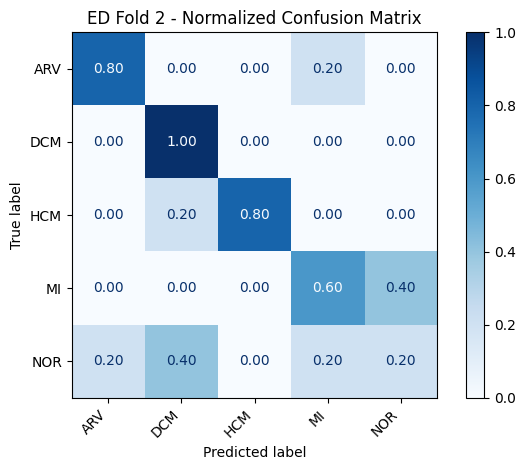


FOLD 3
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=16.00%  val_acc=24.00%  val_f1=12.86%
Epoch 002/150  train_acc=24.00%  val_acc=32.00%  val_f1=18.17%
Epoch 003/150  train_acc=52.00%  val_acc=20.00%  val_f1=8.70%
Epoch 004/150  train_acc=48.00%  val_acc=28.00%  val_f1=18.49%
Epoch 005/150  train_acc=54.67%  val_acc=20.00%  val_f1=7.69%
Epoch 006/150  train_acc=64.00%  val_acc=24.00%  val_f1=18.35%
Epoch 007/150  train_acc=78.67%  val_acc=48.00%  val_f1=42.40%
Epoch 008/150  train_acc=84.00%  val_acc=44.00%  val_f1=37.58%
Epoch 009/150  train_acc=84.00%  val_acc=44.00%  val_f1=36.67%
Epoch 010/150  train_acc=88.00%  val_acc=28.00%  val_f1=20.74%
Epoch 011/150  train_acc=88.00%  val_acc=24.00%  val_f1=19.05%
Epoch 012/150  train_acc=88.00%  val_acc=44.00%  val_f1=37.98%
Epoch 013/150  train_acc=80.00%  val_acc=48.00%  val_f1=46.56%
Epoch 014/150  train_acc=84.00%  val_acc=36.00%  val_f1=26.87%
Epoch 015/150  train_acc=74.67%  val_acc=44.00%  val_f1=37.21%
E

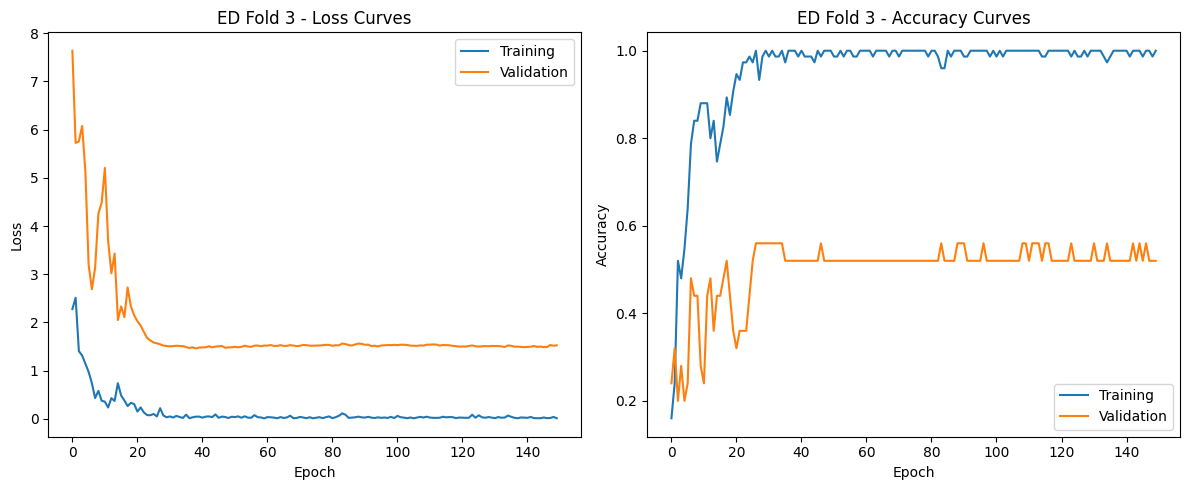


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.8333    1.0000    0.9091         5
         DCM     0.5000    0.6000    0.5455         5
         HCM     0.4000    0.4000    0.4000         5
          MI     0.0000    0.0000    0.0000         5
         NOR     0.5714    0.8000    0.6667         5

    accuracy                         0.5600        25
   macro avg     0.4610    0.5600    0.5042        25
weighted avg     0.4610    0.5600    0.5042        25



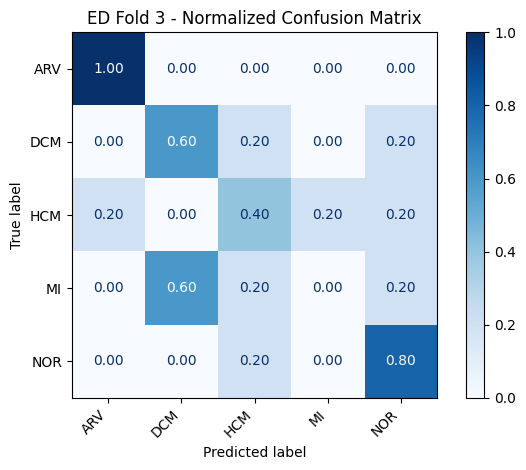


ED SINGLE-PHASE TRAINING SUMMARY (4 FOLDS)
Fold 0 | Val Acc =  52.00% | Macro F1 =  53.99% | Macro Sens =  52.00% | Macro Spec =  88.00%
Fold 1 | Val Acc =  72.00% | Macro F1 =  68.99% | Macro Sens =  72.00% | Macro Spec =  93.00%
Fold 2 | Val Acc =  68.00% | Macro F1 =  66.16% | Macro Sens =  68.00% | Macro Spec =  92.00%
Fold 3 | Val Acc =  56.00% | Macro F1 =  50.42% | Macro Sens =  56.00% | Macro Spec =  89.00%

Mean ± Std across folds
Accuracy         : 62.00 ± 9.52
Macro F1-score   : 59.89 ± 9.06
Macro sensitivity: 62.00 ± 9.52
Macro specificity: 90.50 ± 2.38


In [11]:
import os
import json
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    recall_score
)

# ===================== DEVICE =====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===================== CLASS NAMES =====================
class_names_ED = train_dataset_ED.classes
print("Classes:", class_names_ED)

# ===================== OUTPUT DIRS (KEEP ORIGINAL) =====================
CKPT_DIR = "./checkpoints_ED_final1"
FIG_DIR = "./figures_ED_final1"
META_DIR = "./fold_meta_ED_final1"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# ===================== TRAINING PARAMETERS =====================
num_epochs = 150
batch_size = 20
num_classes = 5

optimizer_name = "Adam"
initial_lr = 1e-3

results_val_acc_ED_final1 = {}
results_val_f1macro_ED_final1 = {}
results_val_sensmacro_ED_final1 = {}
results_val_specmacro_ED_final1 = {}

print("\nStarting 4-fold training for ED single-phase model...\n")

# ===================== HELPER: MACRO SPECIFICITY =====================
def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))


# ===================== MAIN TRAINING LOOP =====================
for fold in range(4):
    train_ids = train_ids_fold[fold]
    val_ids = val_ids_fold[fold]

    print(f"\n{'='*80}")
    print(f"FOLD {fold}")
    print(f"{'='*80}")
    print(f"Training samples   : {len(train_ids)}")
    print(f"Validation samples : {len(val_ids)}")

    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)

    trainloader = DataLoader(
        train_dataset_ED,
        batch_size=batch_size,
        sampler=train_subsampler,
        num_workers=0
    )

    valloader = DataLoader(
        eval_train_dataset_ED,
        batch_size=batch_size,
        sampler=val_subsampler,
        num_workers=0
    )

    dataloaders = {
        "train": trainloader,
        "val": valloader
    }

    dataset_sizes = {
        "train": len(train_ids),
        "val": len(val_ids)
    }

    model = models.resnet34(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_val_sens = 0.0
    best_val_spec = 0.0
    best_epoch = -1

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    # ===================== EPOCH LOOP =====================
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1:03d}/{num_epochs}", end="  ")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            y_true_all = []
            y_pred_all = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * labels.size(0)
                running_corrects += torch.sum(preds == labels.data)

                y_true_all.extend(labels.detach().cpu().numpy().tolist())
                y_pred_all.extend(preds.detach().cpu().numpy().tolist())

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            if phase == "train":
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)
                print(f"train_acc={epoch_acc*100:.2f}%", end="  ")
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)

                val_f1_macro = f1_score(y_true_all, y_pred_all, average="macro")
                val_sens_macro = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
                val_spec_macro = macro_specificity_score(y_true_all, y_pred_all, num_classes=num_classes)

                # ===================== PAPER-STYLE: SAVE BEST CHECKPOINT BY VALIDATION ACCURACY =====================
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_val_f1 = val_f1_macro
                    best_val_sens = val_sens_macro
                    best_val_spec = val_spec_macro
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())

                    ckpt_path = os.path.join(
                        CKPT_DIR,
                        f"ED-resnet34-Adam0.001-fold-{fold}.pth"
                    )
                    torch.save(best_model_wts, ckpt_path)

                print(f"val_acc={epoch_acc*100:.2f}%  val_f1={val_f1_macro*100:.2f}%")

    # ===================== LOAD BEST CHECKPOINT =====================
    model.load_state_dict(best_model_wts)

    results_val_acc_ED_final1[fold] = float(best_val_acc * 100)
    results_val_f1macro_ED_final1[fold] = float(best_val_f1 * 100)
    results_val_sensmacro_ED_final1[fold] = float(best_val_sens * 100)
    results_val_specmacro_ED_final1[fold] = float(best_val_spec * 100)

    # ===================== SAVE METADATA =====================
    fold_meta = {
        "fold": fold,
        "model_selection_metric_within_fold": "validation_accuracy",
        "best_epoch": int(best_epoch),
        "best_val_accuracy": float(best_val_acc * 100),
        "best_val_macro_f1": float(best_val_f1 * 100),
        "best_val_macro_sensitivity": float(best_val_sens * 100),
        "best_val_macro_specificity": float(best_val_spec * 100),
        "checkpoint_path": os.path.join(
            CKPT_DIR,
            f"ED-resnet34-Adam0.001-fold-{fold}.pth"
        )
    }

    with open(os.path.join(META_DIR, f"ED_fold_{fold}_meta.json"), "w", encoding="utf-8") as f:
        json.dump(fold_meta, f, indent=2)

    print("\nBest fold checkpoint summary")
    print(f"Best epoch              : {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
    print(f"Validation macro F1     : {best_val_f1*100:.2f}%")
    print(f"Validation sensitivity  : {best_val_sens*100:.2f}%")
    print(f"Validation specificity  : {best_val_spec*100:.2f}%")

    # ===================== CURVES =====================
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(train_loss_history, label="Training")
    axs[0].plot(val_loss_history, label="Validation")
    axs[0].set_title(f"ED Fold {fold} - Loss Curves")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    axs[1].plot(train_acc_history, label="Training")
    axs[1].plot(val_acc_history, label="Validation")
    axs[1].set_title(f"ED Fold {fold} - Accuracy Curves")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"ED_fold{fold}_loss_accuracy_curves.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # ===================== VALIDATION REPORT =====================
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu()

            y_true_all.extend(labels.tolist())
            y_pred_all.extend(preds.tolist())

    print("\nClassification Report (Validation Set, Best Checkpoint):")
    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=class_names_ED,
        digits=4,
        zero_division=0
    ))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true_all,
        y_pred_all,
        display_labels=class_names_ED,
        cmap=plt.cm.Blues,
        normalize="true",
        values_format=".2f"
    )
    disp.ax_.set_title(f"ED Fold {fold} - Normalized Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"ED_fold{fold}_normalized_confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.show()

# ===================== FINAL SUMMARY =====================
print("\n" + "="*90)
print("ED SINGLE-PHASE TRAINING SUMMARY (4 FOLDS)")
print("="*90)

for f in range(4):
    print(
        f"Fold {f} | "
        f"Val Acc = {results_val_acc_ED_final1[f]:6.2f}% | "
        f"Macro F1 = {results_val_f1macro_ED_final1[f]:6.2f}% | "
        f"Macro Sens = {results_val_sensmacro_ED_final1[f]:6.2f}% | "
        f"Macro Spec = {results_val_specmacro_ED_final1[f]:6.2f}%"
    )

acc_values = np.array(list(results_val_acc_ED_final1.values()))
f1_values = np.array(list(results_val_f1macro_ED_final1.values()))
sens_values = np.array(list(results_val_sensmacro_ED_final1.values()))
spec_values = np.array(list(results_val_specmacro_ED_final1.values()))

print("\nMean ± Std across folds")
print(f"Accuracy         : {acc_values.mean():.2f} ± {acc_values.std(ddof=1):.2f}")
print(f"Macro F1-score   : {f1_values.mean():.2f} ± {f1_values.std(ddof=1):.2f}")
print(f"Macro sensitivity: {sens_values.mean():.2f} ± {sens_values.std(ddof=1):.2f}")
print(f"Macro specificity: {spec_values.mean():.2f} ± {spec_values.std(ddof=1):.2f}")

### 5. Final Evaluation of the ED Single-Phase Model  
**Held-Out Test Set Performance**

#### Overview
This section evaluates the final ED single-phase classification model on the official held-out test set.

#### Model Selection Strategy
- The selected ED configuration is **ResNet-34 with Adam and an initial learning rate of 0.001**
- Four fold-specific models are available from cross-validation training
- The final model is selected using the **highest validation macro F1-score** among the four folds
- The test set is used only for the final evaluation of the selected fold

#### Evaluation Outputs
- overall test accuracy
- macro F1-score
- macro sensitivity
- macro specificity
- full classification report
- normalized confusion matrix
- bootstrap summary based on 1000 resamples

Validation macro F1-score per fold:
Fold 0: 53.99%
Fold 1: 68.99%
Fold 2: 66.16%
Fold 3: 50.42%

Selected fold for final ED test evaluation: Fold 1
Selection criterion: highest validation macro F1-score = 68.99%

=== SINGLE RUN ON TEST SET (50 subjects) ===
Accuracy          : 58.00%
Macro F1-score    : 58.07%
Macro Sensitivity : 58.00%
Macro Specificity : 89.50%

Classification Report (Test Set):
              precision    recall  f1-score   support

         ARV     0.8571    0.6000    0.7059        10
         DCM     0.6667    0.6000    0.6316        10
         HCM     0.6364    0.7000    0.6667        10
          MI     0.3333    0.3000    0.3158        10
         NOR     0.5000    0.7000    0.5833        10

    accuracy                         0.5800        50
   macro avg     0.5987    0.5800    0.5807        50
weighted avg     0.5987    0.5800    0.5807        50



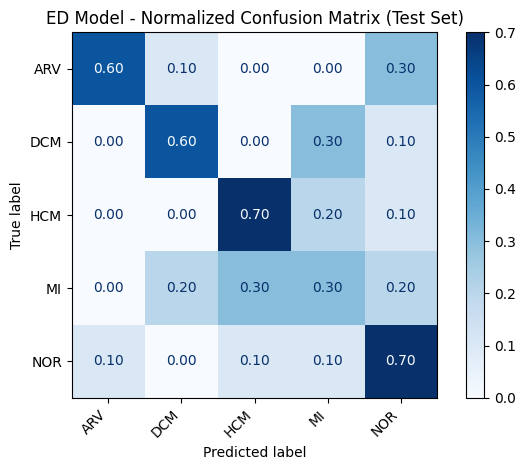


Running bootstrap resampling (n=1000)...

=== BOOTSTRAP TEST RESULTS (n=1000) ===
Accuracy          : 58.06 ± 7.05   (min 32.00 / max 82.00)
Macro F1-score    : 56.89 ± 6.86   (min 31.59 / max 80.36)
Macro Sensitivity : 58.04 ± 6.95   (min 33.01 / max 81.03)
Macro Specificity : 89.52 ± 1.80   (min 83.02 / max 95.51)


In [12]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ===================== TEST LOADER =====================
testloader_ED = DataLoader(
    test_dataset_ED,
    batch_size=25,
    shuffle=False,
    num_workers=0
)

# ===================== SELECT FINAL FOLD FROM TRAINING VALIDATION RESULTS =====================
best_fold = max(results_val_f1macro_ED_final1, key=results_val_f1macro_ED_final1.get)

print("Validation macro F1-score per fold:")
for f in sorted(results_val_f1macro_ED_final1.keys()):
    print(f"Fold {f}: {results_val_f1macro_ED_final1[f]:.2f}%")

print(f"\nSelected fold for final ED test evaluation: Fold {best_fold}")
print(f"Selection criterion: highest validation macro F1-score = {results_val_f1macro_ED_final1[best_fold]:.2f}%")

# ===================== LOAD SELECTED MODEL =====================
model_ED = models.resnet34(weights="IMAGENET1K_V1")
model_ED.fc = nn.Linear(model_ED.fc.in_features, 5)
model_ED.load_state_dict(torch.load(
    f"./checkpoints_ED_final1/ED-resnet34-Adam0.001-fold-{best_fold}.pth",
    map_location=device
))
model_ED = model_ED.to(device)
model_ED.eval()

# ===================== HELPER FUNCTIONS =====================
def eval_once(dataloader, model):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.tolist())

    return np.array(y_true), np.array(y_pred)


def macro_specificity_score(y_true, y_pred, num_classes=5):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))


def compute_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, f1_score, recall_score

    acc = accuracy_score(y_true, y_pred) * 100
    macro_f1 = f1_score(y_true, y_pred, average="macro") * 100
    macro_sens = recall_score(y_true, y_pred, average="macro", zero_division=0) * 100
    macro_spec = macro_specificity_score(y_true, y_pred, num_classes=5) * 100
    return acc, macro_f1, macro_sens, macro_spec


def bootstrap_test(dataloader, model, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)

    y_true, y_pred = eval_once(dataloader, model)
    n = len(y_true)

    boot_metrics = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = y_pred[idx]
        boot_metrics.append(compute_metrics(yt, yp))

    boot_metrics = np.array(boot_metrics)

    mean = boot_metrics.mean(axis=0)
    std = boot_metrics.std(axis=0, ddof=1)
    minv = boot_metrics.min(axis=0)
    maxv = boot_metrics.max(axis=0)

    return mean, std, minv, maxv


# ===================== SINGLE TEST EVALUATION =====================
y_true, y_pred = eval_once(testloader_ED, model_ED)
acc, macro_f1, macro_sens, macro_spec = compute_metrics(y_true, y_pred)

print("\n=== SINGLE RUN ON TEST SET (50 subjects) ===")
print(f"Accuracy          : {acc:.2f}%")
print(f"Macro F1-score    : {macro_f1:.2f}%")
print(f"Macro Sensitivity : {macro_sens:.2f}%")
print(f"Macro Specificity : {macro_spec:.2f}%")

# ===================== CLASSIFICATION REPORT =====================
print("\nClassification Report (Test Set):")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names_ED,
    digits=4,
    zero_division=0
))

# ===================== NORMALIZED CONFUSION MATRIX =====================
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names_ED,
    cmap=plt.cm.Blues,
    normalize='true',
    values_format='.2f'
)
disp.ax_.set_title("ED Model - Normalized Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("ED_test_normalized_confusion_matrix_final1.png", dpi=300, bbox_inches='tight')
plt.show()

# ===================== BOOTSTRAP (n=1000) =====================
print("\nRunning bootstrap resampling (n=1000)...")
mean, std, minv, maxv = bootstrap_test(testloader_ED, model_ED, n_bootstrap=1000)

print("\n=== BOOTSTRAP TEST RESULTS (n=1000) ===")
print(f"Accuracy          : {mean[0]:.2f} ± {std[0]:.2f}   (min {minv[0]:.2f} / max {maxv[0]:.2f})")
print(f"Macro F1-score    : {mean[1]:.2f} ± {std[1]:.2f}   (min {minv[1]:.2f} / max {maxv[1]:.2f})")
print(f"Macro Sensitivity : {mean[2]:.2f} ± {std[2]:.2f}   (min {minv[2]:.2f} / max {maxv[2]:.2f})")
print(f"Macro Specificity : {mean[3]:.2f} ± {std[3]:.2f}   (min {minv[3]:.2f} / max {maxv[3]:.2f})")